In [1]:
import numpy as np
import pandas as pd
#%pip install yfinance
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
warnings.filterwarnings("ignore")

In [2]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"
data_dir = os.path.join(REPO_DIR, "Data")

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

Already up to date.


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
#%pip install sentence-transformers
from sentence_transformers import SentenceTransformer
import zipfile

STOCKS_CSV = "HelpHerInvest/Data/nlp_clean_stock_symbols.csv"

def load_stocks(path=STOCKS_CSV):
    df = pd.read_csv(path)

    # Choose a text field for retrieval
    df["kw_text"] = df["document_clean_tfidf"].fillna(df["document_raw"]).fillna("")
    df["sem_text"] = df["document_raw"].fillna(df["document_clean_tfidf"]).fillna("")

    # Keep only usable rows
    df = df[(df["kw_text"].str.len() > 0) & (df["sem_text"].str.len() > 0)].reset_index(drop=True)
    return df

def build_hybrid_index(df,
                       sbert_model="sentence-transformers/all-MiniLM-L6-v2",
                       tfidf_min_df=2,
                       tfidf_ngram_range=(1,2)):
    # TF-IDF for keyword similarity
    vectorizer = TfidfVectorizer(min_df=tfidf_min_df, max_df=0.95, ngram_range=tfidf_ngram_range)
    X_tfidf = vectorizer.fit_transform(df["kw_text"].astype(str))

    # SBERT embeddings for semantic similarity 
    model = SentenceTransformer(sbert_model)
    X_emb = model.encode(
        df["sem_text"].astype(str).tolist(),
        batch_size=128,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)

    return vectorizer, X_tfidf, model, X_emb

df_stocks = load_stocks(STOCKS_CSV)
vectorizer, X_tfidf, sbert, X_emb = build_hybrid_index(df_stocks)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

In [4]:
def _minmax(x):
    x = np.asarray(x, dtype=np.float32)
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-9)

def build_query_from_df_text_inputs_row(row):
    # Use text_input if present; otherwise combine topics
    t = str(row.get("text_input", "")).strip()
    if t:
        return t
    p = str(row.get("primary_topic", "")).strip()
    s = str(row.get("secondary_topic", "")).strip()
    return (p + " " + s).strip()

def hybrid_retrieve(query, df_stocks, vectorizer, X_tfidf, sbert, X_emb,
                    top_k=50,
                    w_sem=0.65, w_kw=0.35,
                    mmr_lambda=0.80,
                    candidate_pool=500,
                    sector_cap=10):
    """
    w_sem/w_kw: weight semantic vs keyword similarity
    mmr_lambda: higher => more relevance, lower => more diversity
    candidate_pool: retrieve this many by relevance before diversifying to top_k
    sector_cap: max results per sector (set None to disable)
    """

    # keyword similarity (TF-IDF cosine for L2-normalized TF-IDF is dot product)
    q_tfidf = vectorizer.transform([query])
    kw_scores = (X_tfidf @ q_tfidf.T).toarray().ravel()

    # semantic similarity (cosine via normalized vectors)
    q_emb = sbert.encode([query], normalize_embeddings=True).astype(np.float32)  # (1, d)
    sem_scores = (X_emb @ q_emb.T).ravel()

    # combine (normalize each so neither dominates)
    kw_n = _minmax(kw_scores)
    sem_n = _minmax(sem_scores)
    scores = w_sem * sem_n + w_kw * kw_n

    # candidate set
    pool = min(candidate_pool, len(df_stocks))
    cand_idx = np.argpartition(-scores, pool-1)[:pool]
    cand_idx = cand_idx[np.argsort(-scores[cand_idx])]

    # MMR diversification using embedding similarity to reduce redundancy
    selected = []
    selected_set = set()

    # Precompute candidate embeddings
    cand_emb = X_emb[cand_idx]

    # Sector tracking
    sector_counts = {}
    def sector_ok(i):
        if sector_cap is None:
            return True
        sec = df_stocks.loc[i, "sector"]
        sec = sec if isinstance(sec, str) and sec else "Unknown"
        return sector_counts.get(sec, 0) < sector_cap

    for _ in range(min(top_k, len(cand_idx))):
        best_i = None
        best_mmr = -1e9

        for pos, i in enumerate(cand_idx):
            if i in selected_set:
                continue
            if not sector_ok(i):
                continue

            rel = scores[i]

            if not selected:
                mmr = rel
            else:
                # max similarity to already selected (redundancy)
                sim_to_selected = np.max(X_emb[i] @ X_emb[selected].T)
                mmr = mmr_lambda * rel - (1 - mmr_lambda) * sim_to_selected

            if mmr > best_mmr:
                best_mmr = mmr
                best_i = i

        if best_i is None:
            break

        selected.append(best_i)
        selected_set.add(best_i)
        sec = df_stocks.loc[best_i, "sector"]
        sec = sec if isinstance(sec, str) and sec else "Unknown"
        sector_counts[sec] = sector_counts.get(sec, 0) + 1

    out = df_stocks.loc[selected, ["symbol","company_name","sector","industry"]].copy()
    out["hybrid_score"] = scores[selected]
    out = out.sort_values("hybrid_score", ascending=False).reset_index(drop=True)
    return out

In [5]:
# Load the data from the zip file

## PATH NEEDS TO BE UPDATED TO GITHUB DATA PATH
zip_path2 = "HelpHerInvest/Data/final_dataset_20260224v2.csv.zip"
with zipfile.ZipFile(zip_path2) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

## ## ## ## 

tickers = df["Ticker"].unique()
print(f"Unique tickers in final dataset: {len(tickers)}")
print("Size of dataset:",
"Rows:",df.shape[0],
"Columns:",df.shape[1])

Unique tickers in final dataset: 1993
Size of dataset: Rows: 302024 Columns: 18


In [6]:
# count number of positive fwd_excess_return
print("Number of positive fwd_excess_return:", (df["fwd_excess"] > 0).sum())
print("Number of negative fwd_excess_return:", (df["fwd_excess"] < 0).sum())
print("Number of zero fwd_excess_return:", (df["fwd_excess"] == 0).sum())

df_temp = df.copy()

df_temp['y'] = (df_temp['fwd_excess'] > 0).astype(int)

Number of positive fwd_excess_return: 143948
Number of negative fwd_excess_return: 151730
Number of zero fwd_excess_return: 287


In [7]:
df = df_temp.dropna()
print("---  ---  ---")
print("Length of original:",len(df_temp.index))
print("Length of dropped:",len(df.index))

---  ---  ---
Length of original: 302024
Length of dropped: 274511


### Create Dataset 1 - Cross Sectionally Ranked

In [8]:
rank_cols = [
    'mom_1m','mom_3m','mom_6m','mom_12m','mom_12m_ex_1m',
    'rel_3m_spy','rel_6m_spy','rel_12m_spy',
    'vol_3m','vol_6m',
    'drawdown_6m','drawdown_12m',
    'pct_above_200dma'
]

df_rank = df.copy()

for col in rank_cols:
    df_rank[col] = df_rank.groupby("Date")[col].rank(pct=True)

In [9]:
df_rank["fwd_rank"] = df_rank.groupby("Date")["fwd_excess"].rank(pct=True)

df_rank["target"] = pd.cut(
    df_rank["fwd_rank"],
    bins=[0, .2, .4, .6, .8, 1],
    labels=[0,1,2,3,4]
)

df_rank.head(10)

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,...,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,fwd_rank,target
13389,2011-01-31,NVDA,0.997496,0.995826,0.995826,0.814691,0.137730,0.995826,0.995826,0.814691,...,0.928214,0.744157,0.790067,0.995826,0.5483,-0.2287,-0.1639,0,0.030050,0
13390,2011-01-31,GOOGL,0.480801,0.142738,0.636060,0.281302,0.276294,0.142738,0.636060,0.281302,...,0.438230,0.377295,0.476628,0.515025,14.9114,-0.1585,-0.0937,0,0.070117,0
13391,2011-01-31,AAPL,0.729549,0.623539,0.766277,0.909015,0.889816,0.623539,0.766277,0.909015,...,0.222871,0.744157,0.790067,0.747913,10.1670,-0.0330,0.0319,0,0.317195,1
13392,2011-01-31,MSFT,0.381469,0.343907,0.277963,0.121870,0.144407,0.343907,0.277963,0.121870,...,0.181135,0.450751,0.256260,0.288815,21.1071,-0.1246,-0.0597,0,0.101836,0
13393,2011-01-31,AMZN,0.152755,0.280467,0.883973,0.601836,0.727045,0.280467,0.883973,0.601836,...,0.666110,0.220367,0.330968,0.607679,8.4820,0.0894,0.1543,1,0.747913,3
13394,2011-01-31,AVGO,0.479967,0.727045,0.768781,0.868114,0.873957,0.727045,0.768781,0.868114,...,0.817195,0.744157,0.790067,0.839733,2.0278,0.1036,0.1685,1,0.787145,3
13396,2011-01-31,BRK-B,0.545910,0.282137,0.193656,0.191987,0.180301,0.282137,0.193656,0.191987,...,0.076795,0.426544,0.527546,0.192821,81.7500,-0.0459,0.0190,0,0.267947,1
13397,2011-01-31,LLY,0.373122,0.210351,0.120200,0.154424,0.184474,0.210351,0.120200,0.154424,...,0.035893,0.308848,0.414023,0.149833,24.0450,0.0144,0.0793,1,0.492487,2
13398,2011-01-31,WMT,0.665275,0.327212,0.330551,0.196160,0.166945,0.327212,0.330551,0.196160,...,0.010017,0.744157,0.790067,0.309683,13.7084,-0.0774,-0.0126,0,0.181970,0
13399,2011-01-31,JPM,0.760434,0.785476,0.361436,0.322204,0.227880,0.785476,0.361436,0.322204,...,0.493322,0.744157,0.790067,0.526711,29.9574,-0.0440,0.0209,0,0.276711,1


In [10]:
def preprocess_data(df):

    # preprocess the data by dropping rows with missing values
    print("Missing fwd_excess values:")

    df_dropped = df.dropna()
    print("---  ---  ---")
    print("Length of original:",len(df.index))
    print("Length of dropped:",len(df_dropped.index))
    print("Sanity check - missing fwd_excess values after dropping:")
    print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5)) 

   
    
    # Create log_adj_close column
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
    plt.tight_layout()
    plt.show()
    
    return df_dropped

In [11]:
def retrieve_features(df):
    feature_cols = [col for col in df.columns if col not in ["Date", "Ticker", "fwd_excess", "fwd_return", "y","fwd_rank","target"]]
    return feature_cols

In [12]:

def time_split(
    df,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    sort_dates=True
):
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-8:
        raise ValueError("train_frac + val_frac + test_frac must equal 1.0")

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    if sort_dates:
        data = data.sort_values(date_col)

    unique_dates = pd.Series(data[date_col].drop_duplicates()).sort_values().reset_index(drop=True)

    n_dates = len(unique_dates)
    train_end = int(n_dates * train_frac)
    val_end = int(n_dates * (train_frac + val_frac))

    train_dates = unique_dates.iloc[:train_end]
    val_dates = unique_dates.iloc[train_end:val_end]
    test_dates = unique_dates.iloc[val_end:]

    train_df = data[data[date_col].isin(train_dates)].copy()
    val_df = data[data[date_col].isin(val_dates)].copy()
    test_df = data[data[date_col].isin(test_dates)].copy()

    return train_df, val_df, test_df

In [13]:
# Dataset 1 - Using Ranked Features

train_df_rank, val_df_rank, test_df_rank = time_split(df_rank, date_col="Date", train_frac=0.70, val_frac=0.15, test_frac=0.15)
X_train_rank = train_df_rank[retrieve_features(train_df_rank)]
y_train_rank = train_df_rank["y"]
X_val_rank = val_df_rank[retrieve_features(val_df_rank)]
y_val_rank = val_df_rank["y"]
X_test_rank = test_df_rank[retrieve_features(test_df_rank)]
y_test_rank = test_df_rank["y"]

In [14]:
# Winning LightGBM Model - Dataset 1

import lightgbm as lgb

lgb_model1 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=12,
    num_leaves=31,
    class_weight="balanced",    
)

lgb_model1.fit(
    X_train_rank,
    y_train_rank,
    eval_set=[(X_val_rank, y_val_rank)],

)

[LightGBM] [Info] Number of positive: 86755, number of negative: 89946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 176701, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



Cross Sectional Ranked
          Pred 0  Pred 1
Actual 0   13127   11703
Actual 1   11180   11478


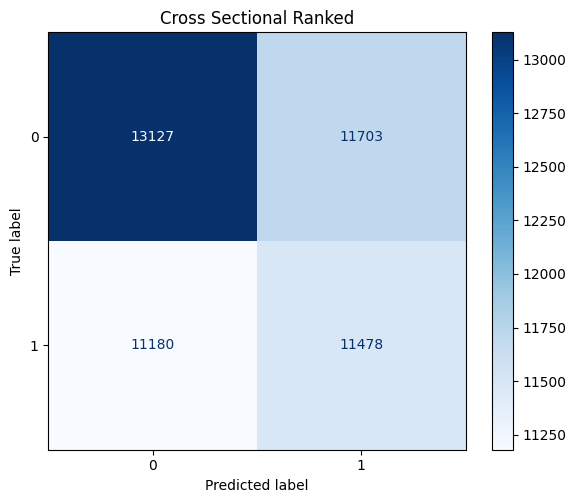

,Pred 0,Pred 1
Actual 0,13127,11703
Actual 1,11180,11478


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def create_confusion_matrix(model, X_val, y_val, name):
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )

    print(f"\n{name}")
    print(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d"
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return cm_df


create_confusion_matrix(lgb_model1, X_val_rank, y_val_rank, "Cross Sectional Ranked")